In [3]:
#bài 1:
import pandas as pd
df = pd.read_csv("sinh_vien.csv")

# Nhóm sinh viên có điểm giữa kỳ từ 7 trở lên
nhom_cao = df[df["diem_giua_ky"] >= 7]

# Nhóm sinh viên có điểm giữa kỳ dưới 7
nhom_thap = df[df["diem_giua_ky"] < 7]

print("So ban co diem giua ky tu 7 tro len:", len(nhom_cao))
print("Ty le qua mon cua nhom diem tu 7 tro len:", round(nhom_cao["qua_mon"].mean(), 4))
print("Ty le qua mon cua nhom con lai:", round(nhom_thap["qua_mon"].mean(), 4))



So ban co diem giua ky tu 7 tro len: 31
Ty le qua mon cua nhom diem tu 7 tro len: 0.9032
Ty le qua mon cua nhom con lai: 0.4831


Nhan xet: Diem giua ky co the phan biet hai nhom neu ty le qua mon cua hai nhom chenh lech ro rang.

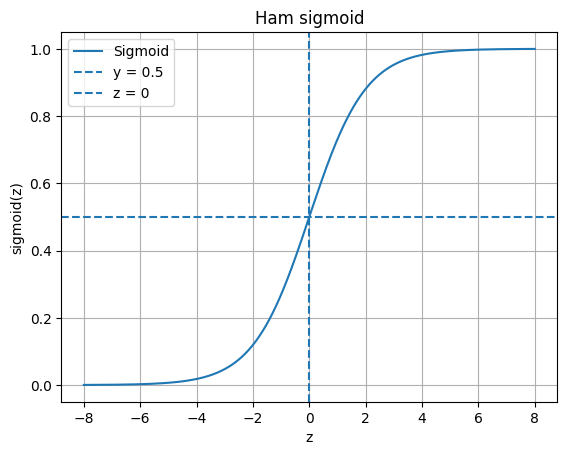

In [4]:
#bài tập 2:
import numpy as np
import matplotlib.pyplot as plt

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

z = np.linspace(-8, 8, 400)
y = sigmoid(z)

plt.plot(z, y, label="Sigmoid")
plt.axhline(0.5, linestyle="--", label="y = 0.5")
plt.axvline(0, linestyle="--", label="z = 0")

plt.xlabel("z")
plt.ylabel("sigmoid(z)")
plt.title("Ham sigmoid")
plt.legend()
plt.grid(True)

plt.savefig("sigmoid.png")
plt.show()

In [6]:
#bai tap 3:
import pandas as pd
from sklearn.linear_model import LogisticRegression
import numpy as np

df = pd.read_csv("sinh_vien.csv")

X = df[["gio_on"]]
y = df["qua_mon"]

mo_hinh = LogisticRegression()
mo_hinh.fit(X, y)

w = float(mo_hinh.coef_[0][0])
b = float(mo_hinh.intercept_[0])

def du_doan(gio):
    z = w * gio + b
    xac_suat = 1 / (1 + np.exp(-z))
    nhan = 1 if xac_suat >= 0.5 else 0

    print(f"So gio on: {gio}")
    print(f"z = {z:.4f}")
    print(f"Xac suat qua mon = {xac_suat:.4f}")
    print(f"Nhãn = {nhan}")
    print()

for gio in [3, 8, 12.89, 18, 26]:
    du_doan(gio)

So gio on: 3
z = -3.8864
Xac suat qua mon = 0.0201
Nhãn = 0

So gio on: 8
z = -1.9223
Xac suat qua mon = 0.1276
Nhãn = 0

So gio on: 12.89
z = -0.0015
Xac suat qua mon = 0.4996
Nhãn = 0

So gio on: 18
z = 2.0059
Xac suat qua mon = 0.8814
Nhãn = 1

So gio on: 26
z = 5.1484
Xac suat qua mon = 0.9942
Nhãn = 1



In [7]:
#bai tap 4:
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split

df = pd.read_csv("sinh_vien.csv")
X = df[["gio_on"]]
y = df["qua_mon"]

# stratify=y giữ đúng tỷ lệ qua và rớt ở cả hai phần sau khi chia
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=17, stratify=y
)

print("So sinh vien de hoc :", len(X_train))
print("So sinh vien de kiem tra:", len(X_test))
print()

mo_hinh = LogisticRegression()
mo_hinh.fit(X_train, y_train)

y_pred = mo_hinh.predict(X_test) #tao ra mo hinh du doan

# Thứ tự bốn ô do scikit-learn quy định là TN, FP, FN, TP
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

print("Ma tran nham lan")
print(f" TN = {tn:2d} doan rot, that su rot")
print(f" FP = {fp:2d} doan qua, that ra rot")
print(f" FN = {fn:2d} doan rot, that ra qua")
print(f" TP = {tp:2d} doan qua, that su qua")
print()

# Tự tính bốn chỉ số bằng công thức
n = len(y_test)

accuracy = (tp + tn) / n
precision = tp / (tp + fp)
recall = tp / (tp + fn)
f1 = 2 * precision * recall / (precision + recall)

print("Tu tinh bang cong thuc:")
print(f"Accuracy = ({tp} + {tn}) / {n} = {accuracy:.4f}")
print(f"Precision = {tp} / ({tp} + {fp}) = {precision:.4f}")
print(f"Recall = {tp} / ({tp} + {fn}) = {recall:.4f}")
print(f"F1 = 2 * {precision:.4f} * {recall:.4f} / "
      f"({precision:.4f} + {recall:.4f}) = {f1:.4f}")

So sinh vien de hoc : 90
So sinh vien de kiem tra: 30

Ma tran nham lan
 TN =  9 doan rot, that su rot
 FP =  3 doan qua, that ra rot
 FN =  1 doan rot, that ra qua
 TP = 17 doan qua, that su qua

Tu tinh bang cong thuc:
Accuracy = (17 + 9) / 30 = 0.8667
Precision = 17 / (17 + 3) = 0.8500
Recall = 17 / (17 + 1) = 0.9444
F1 = 2 * 0.8500 * 0.9444 / (0.8500 + 0.9444) = 0.8947


In [8]:
#bai tap 5:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score
from sklearn.model_selection import train_test_split

df = pd.read_csv("sinh_vien.csv")

X = df[["gio_on"]]
y = df["qua_mon"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=17, stratify=y
)

mo_hinh = LogisticRegression()
mo_hinh.fit(X_train, y_train)

# Lấy xác suất qua môn của tập kiểm tra
p = mo_hinh.predict_proba(X_test)[:, 1]

print("Nguong    F1")

f1_cao_nhat = -1
nguong_tot_nhat = 0

for nguong in np.arange(0.05, 1.0, 0.05): #tao cac nguong
    y_pred = (p >= nguong).astype(int) #thử từng ngưỡng

    f1 = f1_score(y_test, y_pred, zero_division=0) #tính F1

    print(f"{nguong:.2f}      {f1:.4f}")

    if f1 > f1_cao_nhat: #Tìm F1 cao nhất
        f1_cao_nhat = f1
        nguong_tot_nhat = nguong

print()
print(f"Nguong cho F1 cao nhat: {nguong_tot_nhat:.2f}")
print(f"F1 cao nhat: {f1_cao_nhat:.4f}")


Nguong    F1
0.05      0.7826
0.10      0.8182
0.15      0.8182
0.20      0.8571
0.25      0.9000
0.30      0.8947
0.35      0.8947
0.40      0.8947
0.45      0.8947
0.50      0.8947
0.55      0.8889
0.60      0.9412
0.65      0.9412
0.70      0.9091
0.75      0.8750
0.80      0.8387
0.85      0.8000
0.90      0.5600
0.95      0.4348

Nguong cho F1 cao nhat: 0.60
F1 cao nhat: 0.9412


nhận xét: không vì 0.60 cho chúng ta thấy F1 cao nhất 0.9412. bởi vì ngưỡng thấp dễ dự đoán qua Recall thường cao nhưng Precision có thể thấp, còn ngưỡng cao khó dự đoán qua Precision có thể cao nhưng Recall giảm. Ở 0.60, hai yếu tố này đang tạo ra sự cân bằng tốt nhất trong dữ liệu kiểm tra F1 = 0.9412.

In [9]:
#bai tap 6
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_score, recall_score
from sklearn.model_selection import train_test_split

df = pd.read_csv("sinh_vien.csv")

X = df[["gio_on"]]
y = df["qua_mon"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=17, stratify=y
)

mo_hinh = LogisticRegression()
mo_hinh.fit(X_train, y_train)

y_pred = mo_hinh.predict(X_test)

precision_0 = precision_score(y_test, y_pred, pos_label=0) #Hãy coi lớp 0 (rớt môn) là lớp dương để tính Precision.
recall_0 = recall_score(y_test, y_pred, pos_label=0) #Hãy coi lớp 0 (rớt môn) là lớp dương để tính Recall.

print("Danh gia lop rot mon (lop 0):")
print(f"Precision = {precision_0:.4f}")
print(f"Recall = {recall_0:.4f}")

Danh gia lop rot mon (lop 0):
Precision = 0.9000
Recall = 0.7500


NHẬN XÉT: Hai bộ số khác nhau vì Precision và Recall phụ thuộc vào lớp được chọn làm lớp dương. Khi đổi lớp dương từ qua môn (1) sang rớt môn (0), TP, FP và FN được xác định lại nên Precision và Recall cũng thay đổi, dù mô hình và dữ liệu không thay đổi.
Khi xét lớp 1 (qua môn):
TP = dự đoán qua, thực tế qua
FP = dự đoán qua, thực tế rớt
FN = dự đoán rớt, thực tế qua
Nhưng khi xét lớp 0 (rớt môn) thì vai trò thay đổi:
TP mới = dự đoán rớt, thực tế rớt
FP mới = dự đoán rớt, thực tế qua
FN mới = dự đoán qua, thực tế rớt.
